# M2 · Random Forest

**Question this model answers:** do non-linear effects and feature interactions add real signal over Logistic Regression (M1)?

A Random Forest grows hundreds of decision trees. Each tree trains on a random sample of loans and, at every split, considers only a random subset of features. A leaf's PD is the default rate of the training loans in it, and the forest's PD is the **average over all trees**. Trees need no scaling and find interactions by themselves.

Same feature sets as M1 for a fair comparison: **A** (189 features) and **B** (147, without LendingClub's grades; deployable). Fit on train, choose on validation, **test sealed**. Full plan: `IMPLEMENTATION_PLAN.md`.

## 1. Setup

In [1]:
import gc, json, sys, time, platform
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "modeling").is_dir())
sys.path.insert(0, str(ROOT))
from src.modeling import evaluation as ev

# On Kaggle the data comes from the private input dataset; everything else uses the same repo layout.
ON_KAGGLE = Path("/kaggle/input").exists()
if ON_KAGGLE:
    data_dir = next(Path("/kaggle/input").rglob("X_train.parquet")).parent
    ev.DATA_DIR, ev.METADATA_PATH = data_dir, data_dir / "metadata_v2.json"

RESULTS = ROOT / "models" / "M2_random_forest" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
SEED = 42
print("Running on:", "Kaggle" if ON_KAGGLE else "local machine", "| data:", ev.DATA_DIR)
print("Python", platform.python_version(), "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__,
      "| CPU cores", __import__("os").cpu_count())

Running on: Kaggle | data: /kaggle/input/datasets/mitanshkanani/credit-risk-m2-inputs
Python 3.13.15 | pandas 2.3.3 | scikit-learn 1.6.1 | CPU cores 4


## 2. Load data (float32) and define versions A and B
Trees work in float32 internally, so casting up front halves memory without changing results.

In [2]:
X_train, y_train_frame = ev.load_split("train")
X_val, y_val_frame = ev.load_split("validation")
X_train, X_val = X_train.astype("float32"), X_val.astype("float32")
y_train = y_train_frame["target"].astype(int).to_numpy()
y_val = y_val_frame["target"].astype(int).to_numpy()
meta = json.loads(ev.METADATA_PATH.read_text(encoding="utf-8"))
lc_risk = set(meta["feature_groups"]["lc_risk_features"])
features = {
    "A": [c for c in X_train.columns if c != "fico_range_high"],
    "B": [c for c in X_train.columns if c != "fico_range_high" and c not in lc_risk],
}
for v, cols in features.items():
    print(f"Version {v}: {len(cols)} features")
print(f"train {X_train.shape} ({X_train.memory_usage().sum() / 1e6:.0f} MB) | validation {X_val.shape}")

Version A: 189 features
Version B: 147 features
train (388124, 190) (295 MB) | validation (162745, 190)


## 3. Forest builder
Fixed settings: `max_samples=0.5` (each tree sees a random half of the loans: halves time and memory on this 16 GB laptop and adds diversity), `bootstrap=True`, `criterion="gini"`, `n_jobs=-1` (all 12 cores), `random_state=42`.

In [3]:
FIXED = dict(max_samples=0.5, bootstrap=True, criterion="gini", n_jobs=-1, random_state=SEED)

def build_forest(n_estimators, min_samples_leaf, max_features, class_weight=None):
    return RandomForestClassifier(n_estimators=n_estimators, min_samples_leaf=min_samples_leaf,
                                  max_features=max_features, class_weight=class_weight, **FIXED)

build_forest(200, 50, "sqrt")

RandomForestClassifier(max_samples=0.5, min_samples_leaf=50, n_estimators=200,
                       n_jobs=-1, random_state=42)

## 4. Hyper-parameter search (200 trees, validation ROC-AUC)
- `min_samples_leaf` 20 / 50 / 100: minimum loans per leaf (larger = smoother trees).
- `max_features` "sqrt" / 0.3: features tried at each split (fewer = more diverse trees).
- Then `class_weight="balanced_subsample"` is checked once on the best setting.

In [4]:
rows = []

def evaluate_setting(version, leaf, mf, cw):
    cols = features[version]
    start = time.time()
    rf = build_forest(200, leaf, mf, cw).fit(X_train[cols], y_train)
    fit_s = time.time() - start
    p = rf.predict_proba(X_val[cols])[:, 1]
    card = ev.report_card(y_val, p)
    nodes = int(np.mean([e.tree_.node_count for e in rf.estimators_]))
    del rf; gc.collect()
    rows.append({"version": version, "min_samples_leaf": leaf, "max_features": str(mf), "class_weight": str(cw),
                 "val_roc_auc": card["roc_auc"], "val_ks": card["ks"], "val_brier": card["brier"],
                 "val_log_loss": card["log_loss"], "val_mean_pd": card["mean_pd"],
                 "avg_nodes_per_tree": nodes, "fit_seconds": round(fit_s, 1)})
    print(f"{version} leaf={leaf:<3} max_features={str(mf):<4} class_weight={str(cw):<18} "
          f"AUC={card['roc_auc']:.4f}  Brier={card['brier']:.4f}  ({fit_s:.0f}s)")

for version in ("A", "B"):
    for leaf in (20, 50, 100):
        for mf in ("sqrt", 0.3):
            evaluate_setting(version, leaf, mf, None)
    part = pd.DataFrame(rows)
    best = part[(part.version == version)].sort_values("val_roc_auc", ascending=False).iloc[0]
    mf_best = best["max_features"] if best["max_features"] == "sqrt" else float(best["max_features"])
    evaluate_setting(version, int(best["min_samples_leaf"]), mf_best, "balanced_subsample")

tuning = pd.DataFrame(rows)
print(f"\n{len(tuning)} fits, {tuning['fit_seconds'].sum() / 60:.1f} minutes")
tuning.sort_values(["version", "val_roc_auc"], ascending=[True, False]).round(4)

A leaf=20  max_features=sqrt class_weight=None               AUC=0.7335  Brier=0.1451  (65s)
A leaf=20  max_features=0.3  class_weight=None               AUC=0.7334  Brier=0.1441  (234s)
A leaf=50  max_features=sqrt class_weight=None               AUC=0.7333  Brier=0.1455  (56s)
A leaf=50  max_features=0.3  class_weight=None               AUC=0.7340  Brier=0.1444  (202s)
A leaf=100 max_features=sqrt class_weight=None               AUC=0.7324  Brier=0.1460  (50s)
A leaf=100 max_features=0.3  class_weight=None               AUC=0.7332  Brier=0.1448  (179s)
A leaf=50  max_features=0.3  class_weight=balanced_subsample AUC=0.7337  Brier=0.1869  (200s)
B leaf=20  max_features=sqrt class_weight=None               AUC=0.7258  Brier=0.1468  (60s)
B leaf=20  max_features=0.3  class_weight=None               AUC=0.7256  Brier=0.1451  (207s)
B leaf=50  max_features=sqrt class_weight=None               AUC=0.7249  Brier=0.1475  (53s)
B leaf=50  max_features=0.3  class_weight=None               AUC=

,version,min_samples_leaf,max_features,class_weight,val_roc_auc,val_ks,val_brier,val_log_loss,val_mean_pd,avg_nodes_per_tree,fit_seconds
3,A,50,0.3,None,0.7340,0.3405,0.1444,0.4505,0.1747,4443,201.7
6,A,50,0.3,balanced_subsample,0.7337,0.3406,0.1869,0.5539,0.4058,4489,200.1
0,A,20,sqrt,None,0.7335,0.3407,0.1451,0.4519,0.1752,10411,64.6
1,A,20,0.3,None,0.7334,0.3405,0.1441,0.4498,0.1784,9737,234.3
2,A,50,sqrt,None,0.7333,0.3410,0.1455,0.4529,0.1734,4477,56.5
5,A,100,0.3,None,0.7332,0.3386,0.1448,0.4514,0.1729,2298,178.9
4,A,100,sqrt,None,0.7324,0.3386,0.1460,0.4542,0.1721,2264,50.4
7,B,20,sqrt,None,0.7258,0.3252,0.1468,0.4574,0.1816,10591,60.3
8,B,20,0.3,None,0.7256,0.3267,0.1451,0.4533,0.1849,9852,207.1
10,B,50,0.3,None,0.7251,0.3269,0.1455,0.4542,0.1824,4480,178.4


### Selection rule
Highest validation ROC-AUC. Within 0.0005 of the best, prefer `class_weight=None`, then larger `min_samples_leaf` (simpler), then `"sqrt"` (faster).

In [5]:
chosen = {}
for version, part in tuning.groupby("version"):
    best = part["val_roc_auc"].max()
    near = part[part["val_roc_auc"] >= best - 0.0005].copy()
    near["cw_rank"] = (near["class_weight"] != "None").astype(int)
    near["mf_rank"] = (near["max_features"] != "sqrt").astype(int)
    pick = near.sort_values(["cw_rank", "min_samples_leaf", "mf_rank"], ascending=[True, False, True]).iloc[0]
    chosen[version] = {"min_samples_leaf": int(pick["min_samples_leaf"]),
                       "max_features": "sqrt" if pick["max_features"] == "sqrt" else float(pick["max_features"]),
                       "class_weight": None if pick["class_weight"] == "None" else pick["class_weight"]}
    print(f"Version {version}: best AUC {best:.4f}; chosen {chosen[version]} (AUC {pick['val_roc_auc']:.4f} at 200 trees)")

Version A: best AUC 0.7340; chosen {'min_samples_leaf': 50, 'max_features': 0.3, 'class_weight': None} (AUC 0.7340 at 200 trees)
Version B: best AUC 0.7258; chosen {'min_samples_leaf': 20, 'max_features': 'sqrt', 'class_weight': None} (AUC 0.7258 at 200 trees)


## 5. Final forests (500 trees)
Each version is fitted, scored, analysed and saved, then removed from memory before the next one.

In [6]:
TREE_STEPS = [25, 50, 100, 200, 300, 400, 500]
preds, cards, tree_curves, importances, model_info = {}, {}, [], [], {}

def tree_curve(rf, X):
    # validation AUC using only the first k trees (forest PD = mean over trees)
    total, out, k = np.zeros(len(X)), [], 0
    Xn = X.to_numpy()
    for i, est in enumerate(rf.estimators_, start=1):
        total += est.predict_proba(Xn)[:, 1]
        if i in TREE_STEPS:
            out.append({"n_trees": i, "val_roc_auc": roc_auc_score(y_val, total / i)})
    return out

def permutation_auc_drop(rf, X, y, cols, n_repeats=3, sample=20000):
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(X), size=sample, replace=False)
    Xs, ys = X.iloc[idx].copy(), y[idx]
    base = roc_auc_score(ys, rf.predict_proba(Xs)[:, 1])
    drops = {}
    for c in cols:
        original = Xs[c].to_numpy().copy()
        d = []
        for _ in range(n_repeats):
            Xs[c] = rng.permutation(original)
            d.append(base - roc_auc_score(ys, rf.predict_proba(Xs)[:, 1]))
        Xs[c] = original
        drops[c] = float(np.mean(d))
    return drops

for version in ("A", "B"):
    cols, cfg = features[version], chosen[version]
    start = time.time()
    rf = build_forest(500, cfg["min_samples_leaf"], cfg["max_features"], cfg["class_weight"]).fit(X_train[cols], y_train)
    fit_s = time.time() - start
    preds[version] = {"train": rf.predict_proba(X_train[cols])[:, 1], "validation": rf.predict_proba(X_val[cols])[:, 1]}
    cards[version] = {s: ev.report_card(y, preds[version][s]) for s, y in (("train", y_train), ("validation", y_val))}
    tree_curves += [dict(r, version=version) for r in tree_curve(rf, X_val[cols])]
    mdi = pd.Series(rf.feature_importances_, index=cols).sort_values(ascending=False)
    perm = permutation_auc_drop(rf, X_val[cols], y_val, list(mdi.index[:20]))
    importances.append(pd.DataFrame({"version": version, "feature": mdi.index, "mdi_importance": mdi.values,
                                     "permutation_auc_drop": [perm.get(c, np.nan) for c in mdi.index]}))
    model_info[version] = {"fit_seconds": round(fit_s, 1),
                           "avg_nodes_per_tree": int(np.mean([e.tree_.node_count for e in rf.estimators_])),
                           "avg_depth": float(np.mean([e.get_depth() for e in rf.estimators_]))}
    if not ON_KAGGLE:   # forests are hundreds of MB; on Kaggle only predictions are kept (refit is reproducible, seed 42)
        joblib.dump(rf, RESULTS / f"m2_{version}.joblib", compress=3)
    print(f"Version {version}: 500 trees in {fit_s / 60:.1f} min | validation AUC {cards[version]['validation']['roc_auc']:.4f} "
          f"| avg depth {model_info[version]['avg_depth']:.1f}")
    del rf; gc.collect()

importance = pd.concat(importances, ignore_index=True)
pd.DataFrame(model_info).T

Version A: 500 trees in 8.4 min | validation AUC 0.7345 | avg depth 27.7
Version B: 500 trees in 2.5 min | validation AUC 0.7270 | avg depth 31.4


,fit_seconds,avg_nodes_per_tree,avg_depth
A,506.8,4445.0,27.718
B,152.2,10592.0,31.366


## 6. Results vs M0 and M1 (same version)

In [7]:
board = pd.read_csv(ev.LEADERBOARD_PATH)
keys = ["roc_auc", "ks", "pr_auc", "brier", "log_loss", "mean_pd", "calibration_gap"]
def board_row(model, version, split):
    r = board[(board.model == model) & (board.version == version) & (board.split == split)].iloc[0]
    return {k: r[k] for k in keys}
compare = pd.DataFrame({
    "M0 (val)": board_row("M0", "A", "validation"),
    "M1-A (val)": board_row("M1", "A", "validation"),
    "M2-A (train)": {k: cards["A"]["train"][k] for k in keys},
    "M2-A (val)": {k: cards["A"]["validation"][k] for k in keys},
    "M1-B (val)": board_row("M1", "B", "validation"),
    "M2-B (train)": {k: cards["B"]["train"][k] for k in keys},
    "M2-B (val)": {k: cards["B"]["validation"][k] for k in keys},
})
compare.astype(float).round(4)

,M0 (val),M1-A (val),M2-A (train),M2-A (val),M1-B (val),M2-B (train),M2-B (val)
roc_auc,0.5000,0.7335,0.7902,0.7345,0.7252,0.8548,0.7270
ks,0.0000,0.3421,0.4320,0.3410,0.3262,0.5517,0.3284
pr_auc,0.2035,0.4120,0.4444,0.4152,0.4045,0.5555,0.4084
brier,0.1631,0.1445,0.1215,0.1443,0.1449,0.1173,0.1467
log_loss,0.5085,0.4506,0.3876,0.4503,0.4529,0.3767,0.4571
mean_pd,0.1724,0.1773,0.1728,0.1749,0.1837,0.1730,0.1817
calibration_gap,-0.0311,-0.0262,0.0004,-0.0286,-0.0198,0.0006,-0.0218


In [8]:
for v in ("A", "B"):
    m1 = board_row("M1", v, "validation"); m2 = cards[v]["validation"]
    print(f"Version {v}: M2 - M1 on validation -> ROC-AUC {m2['roc_auc'] - m1['roc_auc']:+.4f}, "
          f"KS {m2['ks'] - m1['ks']:+.4f}, Brier {m2['brier'] - m1['brier']:+.4f}, log loss {m2['log_loss'] - m1['log_loss']:+.4f}")

Version A: M2 - M1 on validation -> ROC-AUC +0.0010, KS -0.0010, Brier -0.0001, log loss -0.0004
Version B: M2 - M1 on validation -> ROC-AUC +0.0018, KS +0.0022, Brier +0.0019, log loss +0.0042


## 7. Sanity checks
A forest scores its own training loans optimistically (each loan sat in the training sample of about half the trees), so a train/validation gap is expected. It is reported, not used as a pass/fail.

In [9]:
m0 = board_row("M0", "A", "validation")
checks = []
for v in ("A", "B"):
    val, tr = cards[v]["validation"], cards[v]["train"]
    checks += [
        (v, "beats M0 ROC-AUC", val["roc_auc"] > m0["roc_auc"], f"{val['roc_auc']:.4f}"),
        (v, "beats M0 Brier", val["brier"] < m0["brier"], f"{val['brier']:.4f} vs {m0['brier']:.4f}"),
        (v, "below 0.80 leakage flag", val["roc_auc"] < 0.80, f"{val['roc_auc']:.4f}"),
        (v, "train vs validation ROC-AUC (info)", True, f"{tr['roc_auc']:.4f} vs {val['roc_auc']:.4f}"),
    ]
pd.DataFrame(checks, columns=["version", "check", "passed", "detail"])

,version,check,passed,detail
0,A,beats M0 ROC-AUC,True,0.7345
1,A,beats M0 Brier,True,0.1443 vs 0.1631
2,A,below 0.80 leakage flag,True,0.7345
3,A,train vs validation ROC-AUC (info),True,0.7902 vs 0.7345
4,B,beats M0 ROC-AUC,True,0.7270
5,B,beats M0 Brier,True,0.1467 vs 0.1631
6,B,below 0.80 leakage flag,True,0.7270
7,B,train vs validation ROC-AUC (info),True,0.8548 vs 0.7270


## 8. How many trees are enough?

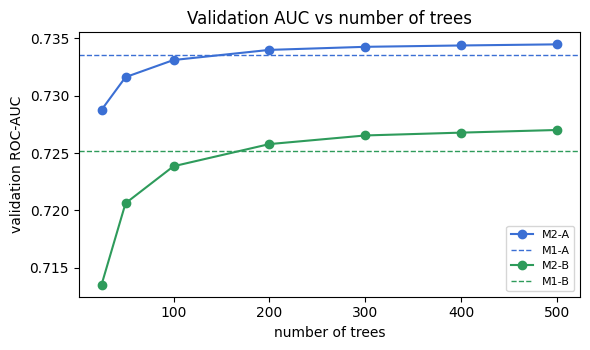

version,A,B
n_trees,,
25,0.7288,0.7135
50,0.7316,0.7206
100,0.7331,0.7239
200,0.7340,0.7258
300,0.7342,0.7265
400,0.7344,0.7268
500,0.7345,0.7270


In [10]:
curve_df = pd.DataFrame(tree_curves)
fig, ax = plt.subplots(figsize=(6, 3.6))
for v, color in (("A", "#3b6fd4"), ("B", "#2e9b5b")):
    part = curve_df[curve_df.version == v]
    ax.plot(part["n_trees"], part["val_roc_auc"], marker="o", color=color, label=f"M2-{v}")
    ax.axhline(board_row("M1", v, "validation")["roc_auc"], ls="--", color=color, lw=1, label=f"M1-{v}")
ax.set_xlabel("number of trees"); ax.set_ylabel("validation ROC-AUC"); ax.set_title("Validation AUC vs number of trees")
ax.legend(fontsize=8); plt.tight_layout(); plt.savefig(RESULTS / "m2_tree_curve.png", dpi=150); plt.show()
curve_df.pivot(index="n_trees", columns="version", values="val_roc_auc").round(4)

## 9. Feature importance (version B)
- **MDI**: how much each feature reduced impurity across all splits. Fast, but biased toward continuous features with many split points.
- **Permutation**: drop in validation ROC-AUC when the feature is shuffled (20,000-row sample, 3 repeats, top 20 by MDI). This is the more honest measure.

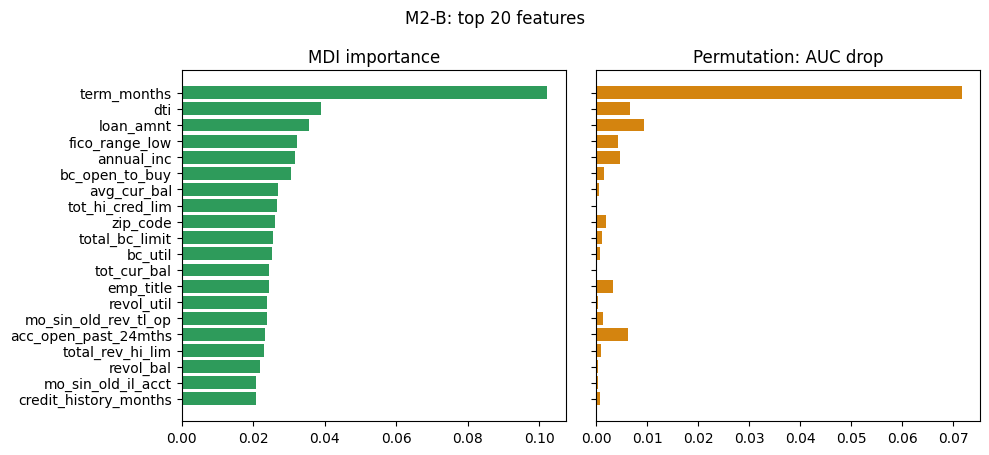

,feature,mdi_importance,permutation_auc_drop
189,term_months,0.1023,0.0717
190,dti,0.0391,0.0067
191,loan_amnt,0.0355,0.0094
192,fico_range_low,0.0323,0.0044
193,annual_inc,0.0316,0.0047
194,bc_open_to_buy,0.0306,0.0016
195,avg_cur_bal,0.0268,0.0006
196,tot_hi_cred_lim,0.0267,0.0002
197,zip_code,0.0260,0.0020
198,total_bc_limit,0.0255,0.0013


In [11]:
imp_b = importance[importance.version == "B"].head(20)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharey=True)
order = imp_b.iloc[::-1]
axes[0].barh(order["feature"], order["mdi_importance"], color="#2e9b5b"); axes[0].set_title("MDI importance")
axes[1].barh(order["feature"], order["permutation_auc_drop"], color="#d4840f"); axes[1].set_title("Permutation: AUC drop")
fig.suptitle("M2-B: top 20 features"); plt.tight_layout()
plt.savefig(RESULTS / "m2_importance.png", dpi=150); plt.show()
imp_b[["feature", "mdi_importance", "permutation_auc_drop"]].round(4)

## 10. Calibration on validation

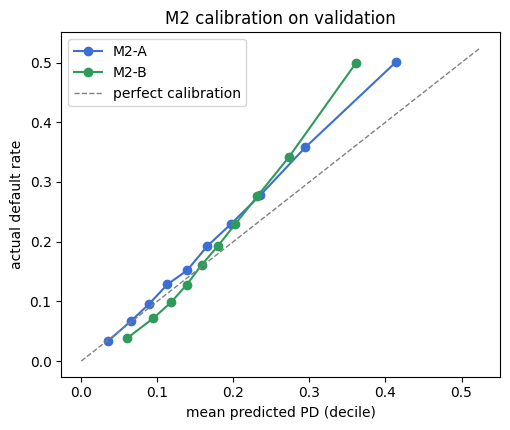

,predicted,actual,version
bin,,,
0,0.0357,0.0340,A
1,0.0655,0.0672,A
2,0.0893,0.0957,A
3,0.1133,0.1284,A
4,0.1390,0.1517,A
5,0.1660,0.1928,A
6,0.1963,0.2290,A
7,0.2351,0.2775,A
8,0.2946,0.3579,A


In [12]:
fig, ax = plt.subplots(figsize=(5.2, 4.4))
calib_rows = []
for v, color in (("A", "#3b6fd4"), ("B", "#2e9b5b")):
    frame = pd.DataFrame({"p": preds[v]["validation"], "y": y_val})
    frame["bin"] = pd.qcut(frame["p"], 10, labels=False, duplicates="drop")
    g = frame.groupby("bin").agg(predicted=("p", "mean"), actual=("y", "mean"))
    ax.plot(g["predicted"], g["actual"], marker="o", color=color, label=f"M2-{v}")
    calib_rows.append(g.assign(version=v))
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], ls="--", color="grey", lw=1, label="perfect calibration")
ax.set_xlabel("mean predicted PD (decile)"); ax.set_ylabel("actual default rate")
ax.set_title("M2 calibration on validation"); ax.legend(); plt.tight_layout()
plt.savefig(RESULTS / "m2_calibration.png", dpi=150); plt.show()
pd.concat(calib_rows).round(4)

## 11. Approval-rate vs bad-rate curve (validation, version B)

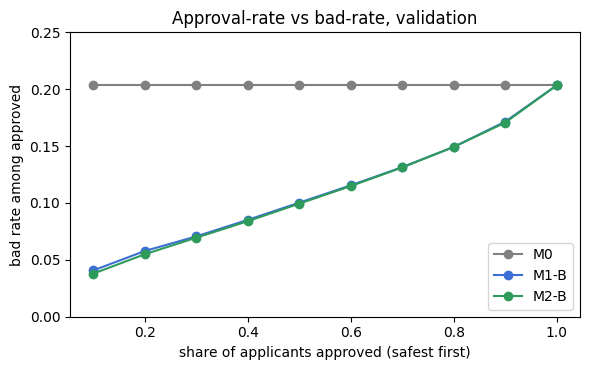

Agreement between M1-B and M2-B rankings (Spearman): 0.9374


model,M0,M1-B,M2-B
approval_rate,,,
0.1,0.2035,0.0406,0.0379
0.2,0.2035,0.0578,0.0549
0.3,0.2035,0.0706,0.0695
0.4,0.2035,0.0851,0.0840
0.5,0.2035,0.1003,0.0994
0.6,0.2035,0.1155,0.1149
0.7,0.2035,0.1315,0.1313
0.8,0.2035,0.1493,0.1493
0.9,0.2035,0.1715,0.1707


In [13]:
# M1-B validation predictions were saved by M1 (same loan order, checked by id)
m1_pred = pd.read_parquet(ROOT / "models" / "M1_logistic_regression" / "results" / "m1_B_validation_pd.parquet")
assert (m1_pred["id"].astype(str).to_numpy() == y_val_frame["id"].astype(str).to_numpy()).all()
p_m1_b = m1_pred["pd_m1_B"].to_numpy()
curves = pd.concat([
    ev.approval_curve(y_val, np.full(len(y_val), m0["mean_pd"])).assign(model="M0"),
    ev.approval_curve(y_val, p_m1_b).assign(model="M1-B"),
    ev.approval_curve(y_val, preds["B"]["validation"]).assign(model="M2-B"),
])
fig, ax = plt.subplots(figsize=(6, 3.8))
for name, color in (("M0", "grey"), ("M1-B", "#3b6fd4"), ("M2-B", "#2e9b5b")):
    part = curves[curves.model == name]
    ax.plot(part["approval_rate"], part["bad_rate_among_approved"], marker="o", color=color, label=name)
ax.set_xlabel("share of applicants approved (safest first)"); ax.set_ylabel("bad rate among approved")
ax.set_title("Approval-rate vs bad-rate, validation"); ax.legend(); ax.set_ylim(0, 0.25); plt.tight_layout()
plt.savefig(RESULTS / "m2_approval_curve.png", dpi=150); plt.show()
print("Agreement between M1-B and M2-B rankings (Spearman):",
      round(pd.Series(p_m1_b).corr(pd.Series(preds["B"]["validation"]), method="spearman"), 4))
curves.pivot(index="approval_rate", columns="model", values="bad_rate_among_approved").round(4)

## 12. Segments and A vs B

In [14]:
segments = pd.concat([
    ev.segment_report(y_val, preds[v]["validation"], X_val["term_months"], "term_months").assign(version=v)
    for v in ("A", "B")
])
a, b = cards["A"]["validation"], cards["B"]["validation"]
print(f"A minus B (validation): ROC-AUC {a['roc_auc'] - b['roc_auc']:+.4f}; "
      f"B keeps {(b['roc_auc'] - 0.5) / (a['roc_auc'] - 0.5):.1%} of A's ranking power above a coin flip")
segments[["version", "term_months", "rows", "default_rate", "mean_pd", "calibration_gap", "roc_auc", "ks", "brier"]].round(4)

A minus B (validation): ROC-AUC +0.0075; B keeps 96.8% of A's ranking power above a coin flip


,version,term_months,rows,default_rate,mean_pd,calibration_gap,roc_auc,ks,brier
0,A,36.0,120790,0.1512,0.1338,-0.0175,0.6999,0.2910,0.1205
1,A,60.0,41955,0.3540,0.2932,-0.0607,0.6775,0.2608,0.2130
0,B,36.0,120790,0.1512,0.1504,-0.0009,0.6888,0.2782,0.1216
1,B,60.0,41955,0.3540,0.2720,-0.0820,0.6716,0.2455,0.2191


## 13. Save results

In [15]:
tuning.to_csv(RESULTS / "m2_tuning_results.csv", index=False)
curve_df.to_csv(RESULTS / "m2_tree_curve.csv", index=False)
importance.to_csv(RESULTS / "m2_feature_importance.csv", index=False)
segments.to_csv(RESULTS / "m2_segment_metrics.csv", index=False)
curves.to_csv(RESULTS / "m2_approval_curve.csv", index=False)
pd.DataFrame({"id": y_val_frame["id"].astype(str), "pd_m2_A": preds["A"]["validation"],
              "pd_m2_B": preds["B"]["validation"]}).to_parquet(RESULTS / "m2_validation_pd.parquet", index=False)
summary = {
    "model": "M2", "name": "Random Forest", "estimator": "sklearn.ensemble.RandomForestClassifier",
    "fixed_parameters": {**{k: v for k, v in FIXED.items() if k != "n_jobs"}, "n_estimators_tuning": 200, "n_estimators_final": 500},
    "search_space": {"min_samples_leaf": [20, 50, 100], "max_features": ["sqrt", 0.3],
                     "class_weight": "balanced_subsample checked on the best setting"},
    "selection_rule": "max validation ROC-AUC; within 0.0005 prefer class_weight=None, larger min_samples_leaf, then sqrt",
    "chosen": chosen, "model_info": model_info, "n_features": {v: len(c) for v, c in features.items()},
    "environment": {"python": platform.python_version(), "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
                    "platform": "Kaggle CPU notebook" if ON_KAGGLE else "local", "cpu_cores": __import__("os").cpu_count()},
    "model_files_saved": not ON_KAGGLE,
    "metrics": cards, "test_split": "sealed",
}
(RESULTS / "m2_metrics.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
for v in ("A", "B"):
    cfg = chosen[v]
    note = f"500 trees, leaf={cfg['min_samples_leaf']}, max_features={cfg['max_features']}, class_weight={cfg['class_weight']}"
    for split in ("train", "validation"):
        board = ev.update_leaderboard("M2", v, split, cards[v][split], notes=note)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))
board[board.split == "validation"].round(4)

Saved: ['m2_approval_curve.csv', 'm2_approval_curve.png', 'm2_calibration.png', 'm2_feature_importance.csv', 'm2_importance.png', 'm2_metrics.json', 'm2_segment_metrics.csv', 'm2_tree_curve.csv', 'm2_tree_curve.png', 'm2_tuning_results.csv', 'm2_validation_pd.parquet']


,model,version,split,rows,default_rate,mean_pd,roc_auc,pr_auc,ks,brier,log_loss,calibration_gap,notes
1,M0,A,validation,162745,0.2035,0.1724,0.5000,0.2035,0.0000,0.1631,0.5085,-0.0311,constant PD = train default rate
3,M0,B,validation,162745,0.2035,0.1724,0.5000,0.2035,0.0000,0.1631,0.5085,-0.0311,constant PD = train default rate
5,M1,A,validation,162745,0.2035,0.1773,0.7335,0.4120,0.3421,0.1445,0.4506,-0.0262,"log+scale, C=0.0001, class_weight=None"
7,M1,B,validation,162745,0.2035,0.1837,0.7252,0.4045,0.3262,0.1449,0.4529,-0.0198,"log+scale, C=0.001, class_weight=None"
9,M2,A,validation,162745,0.2035,0.1749,0.7345,0.4152,0.3410,0.1443,0.4503,-0.0286,"500 trees, leaf=50, max_features=0.3, class_we..."
11,M2,B,validation,162745,0.2035,0.1817,0.7270,0.4084,0.3284,0.1467,0.4571,-0.0218,"500 trees, leaf=20, max_features=sqrt, class_w..."


## 14. Conclusion

In [16]:
for v in ("A", "B"):
    m1, m2 = board_row("M1", v, "validation"), cards[v]["validation"]
    print(f"Version {v}: M1 ROC-AUC {m1['roc_auc']:.4f} -> M2 {m2['roc_auc']:.4f} ({m2['roc_auc'] - m1['roc_auc']:+.4f}); "
          f"Brier {m1['brier']:.4f} -> {m2['brier']:.4f}")
gain = cards["B"]["validation"]["roc_auc"] - board_row("M1", "B", "validation")["roc_auc"]
verdict = ("Random Forest clearly beats Logistic Regression: non-linear effects matter." if gain > 0.005 else
           "Random Forest does NOT clearly beat Logistic Regression (gain <= 0.005 ROC-AUC): averaging independent trees "
           "finds little extra signal here. Boosting (M3), which builds trees that correct each other's mistakes, is the real test.")
print("\nVerdict:", verdict)

Version A: M1 ROC-AUC 0.7335 -> M2 0.7345 (+0.0010); Brier 0.1445 -> 0.1443
Version B: M1 ROC-AUC 0.7252 -> M2 0.7270 (+0.0018); Brier 0.1449 -> 0.1467

Verdict: Random Forest does NOT clearly beat Logistic Regression (gain <= 0.005 ROC-AUC): averaging independent trees finds little extra signal here. Boosting (M3), which builds trees that correct each other's mistakes, is the real test.
